In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#  Loan Approval Prediction
# Step 1 : import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [4]:
# Step 2: Load datasets

In [5]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")


In [6]:
# Step:3 basic exploration of data

In [7]:
print(train.head())
print(train.info())
print(train.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP100000   Male      No          0      Graduate            No   
1  LP100001   Male     Yes          1      Graduate            No   
2  LP100002   Male     Yes          0      Graduate           Yes   
3  LP100003   Male     Yes          0  Not Graduate            No   
4  LP100004   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [8]:
print(train.tail())

        Loan_ID  Gender Married Dependents     Education Self_Employed  \
10609  LP110609  Female      No         3+  Not Graduate            No   
10610  LP110610  Female     Yes          2  Not Graduate            No   
10611  LP110611  Female     Yes        NaN      Graduate            No   
10612  LP110612    Male     Yes          1      Graduate            No   
10613  LP110613    Male     Yes          0      Graduate            No   

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
10609             4335                0.0       301.0             300.0   
10610             3789             5281.0       243.0             360.0   
10611             3097              492.0       119.0              84.0   
10612             3033             2989.0       310.0             300.0   
10613             3718              665.0        91.0             360.0   

       Credit_History Property_Area Loan_Status  
10609             1.0         Rural           N  
1061

In [9]:
#step 4 : check missing values

In [10]:
train.isnull().sum()

Loan_ID                0
Gender               122
Married               45
Dependents           241
Education              0
Self_Employed        355
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount           242
Loan_Amount_Term     161
Credit_History       490
Property_Area          0
Loan_Status            0
dtype: int64

In [11]:
# step 5 : handling missing values

In [12]:
# categorical => mode

train['Gender'] = train['Gender'].fillna(train['Gender'].mode()[0])
train['Married'] = train['Married'].fillna(train['Married'].mode()[0])
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].mode()[0])
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].mode()[0])
# numeric=>median
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].median())

train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].median())

In [13]:
# step 6 : EDA

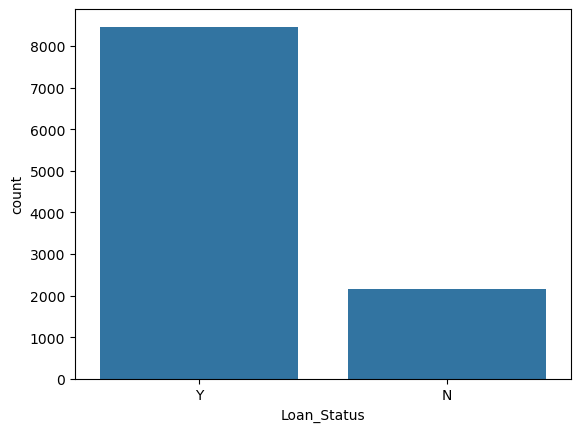

In [14]:
# Target variable
# shows how many loan approved or rejected
sns.countplot(x='Loan_Status', data=train)
plt.show()

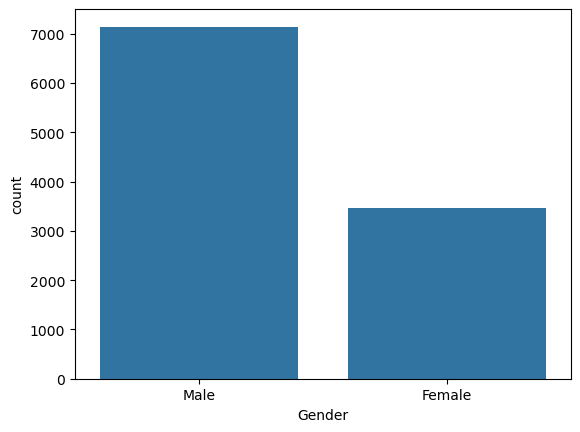

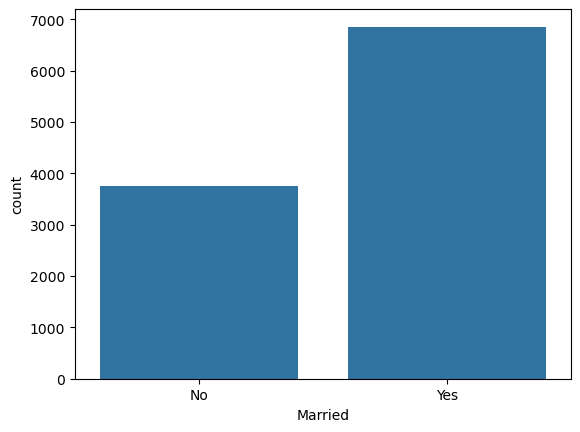

In [15]:
# categorical features
# distribution of gender AND married
sns.countplot(x='Gender', data=train)
plt.show()

sns.countplot(x='Married', data=train)
plt.show()

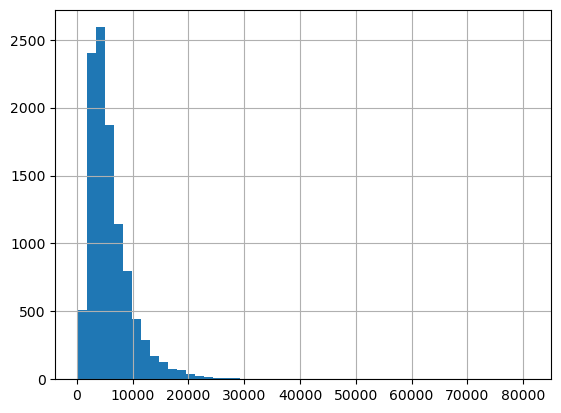

In [16]:
# numeric features
 # distribution of income
train['ApplicantIncome'].hist(bins=50)
plt.show()

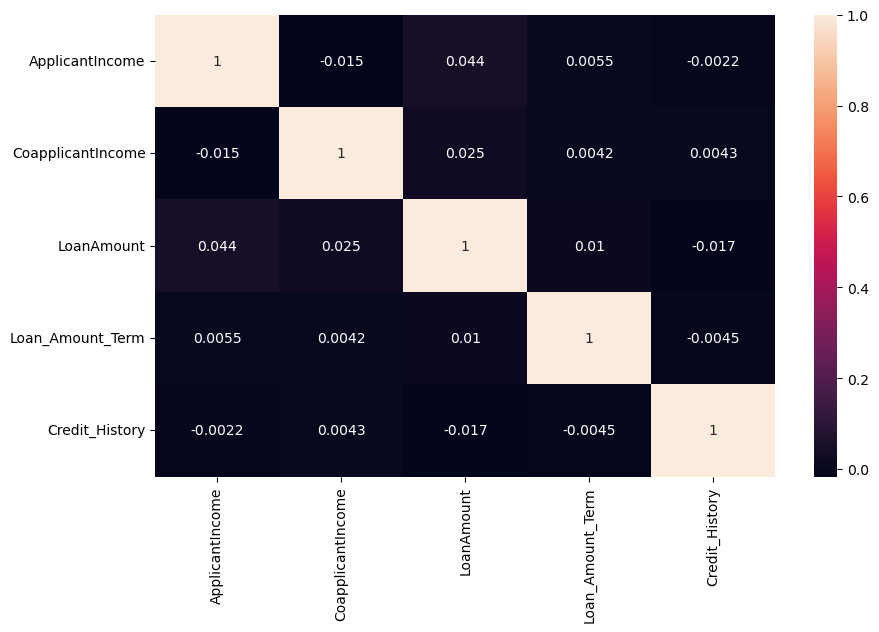

In [17]:
# correlation heatmap
numeric_data = train.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

In [18]:
train.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [19]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,No,0,Graduate,No,5849,0.0,132.0,360.0,1.0,Urban,Y
1,LP100001,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP100002,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP100003,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP100004,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10609,LP110609,Female,No,3+,Not Graduate,No,4335,0.0,301.0,300.0,1.0,Rural,N
10610,LP110610,Female,Yes,2,Not Graduate,No,3789,5281.0,243.0,360.0,1.0,Urban,Y
10611,LP110611,Female,Yes,0,Graduate,No,3097,492.0,119.0,84.0,1.0,Urban,Y
10612,LP110612,Male,Yes,1,Graduate,No,3033,2989.0,310.0,300.0,0.0,Semiurban,N


In [20]:
# step 6 : handle outliers

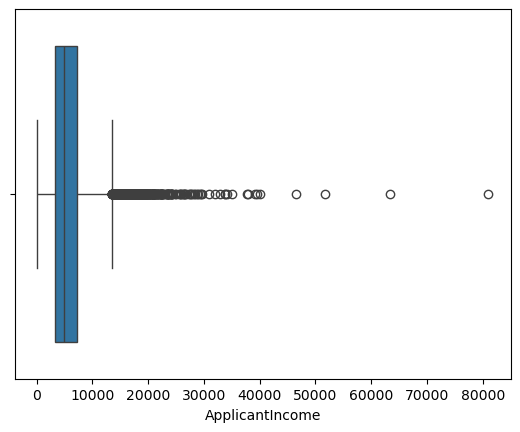

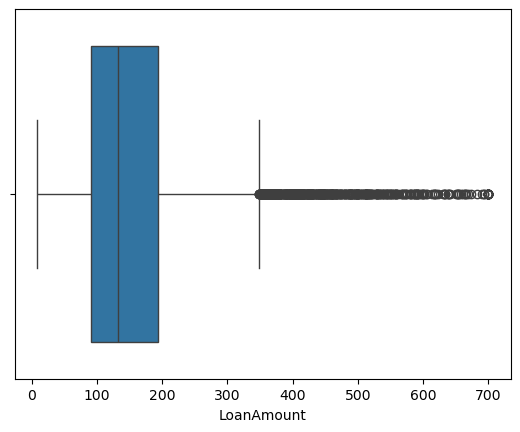

In [21]:
# outlier detection
sns.boxplot(x=train['ApplicantIncome'])
plt.show()

sns.boxplot(x=train['LoanAmount'])
plt.show() 

In [22]:
# fix using log transforamation

In [23]:
train['ApplicantIncome_log'] = np.log(train['ApplicantIncome'])
train['LoanAmount_log'] = np.log(train['LoanAmount'])

In [24]:
print(train['ApplicantIncome'].skew())
(train['LoanAmount'].skew())

3.0164026866218285


np.float64(1.896683709629924)

In [25]:
# step 4:  data cleaning
# Fix Dependents Columnn
train['Dependents'] = train['Dependents'].replace('3+',3)
train['Dependents'] = train['Dependents'].astype(int)

In [26]:
train


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log
0,LP100000,Male,No,0,Graduate,No,5849,0.0,132.0,360.0,1.0,Urban,Y,8.674026,4.882802
1,LP100001,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,8.430109,4.852030
2,LP100002,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,8.006368,4.189655
3,LP100003,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.856707,4.787492
4,LP100004,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,8.699515,4.948760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10609,LP110609,Female,No,3,Not Graduate,No,4335,0.0,301.0,300.0,1.0,Rural,N,8.374477,5.707110
10610,LP110610,Female,Yes,2,Not Graduate,No,3789,5281.0,243.0,360.0,1.0,Urban,Y,8.239857,5.493061
10611,LP110611,Female,Yes,0,Graduate,No,3097,492.0,119.0,84.0,1.0,Urban,Y,8.038189,4.779123
10612,LP110612,Male,Yes,1,Graduate,No,3033,2989.0,310.0,300.0,0.0,Semiurban,N,8.017308,5.736572


In [27]:
# step 5:feature engineering


In [28]:
# Total income 
train['TotalIncome'] = train['ApplicantIncome'] + train['CoapplicantIncome'] 

In [29]:
#  loan income ratio 
train['LoanIncomeRatio'] = train['LoanAmount'] / train['TotalIncome']

In [30]:
train['Total_Income_log'] = np.log(train['TotalIncome'])

In [31]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log,TotalIncome,LoanIncomeRatio,Total_Income_log
0,LP100000,Male,No,0,Graduate,No,5849,0.0,132.0,360.0,1.0,Urban,Y,8.674026,4.882802,5849.0,0.022568,8.674026
1,LP100001,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,8.430109,4.852030,6091.0,0.021015,8.714568
2,LP100002,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,8.006368,4.189655,3000.0,0.022000,8.006368
3,LP100003,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.856707,4.787492,4941.0,0.024287,8.505323
4,LP100004,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,8.699515,4.948760,6000.0,0.023500,8.699515


In [32]:
train.shape

(10614, 18)

In [33]:
# step 6 :Encoding data

In [34]:
le = LabelEncoder()
loan_col = ['Gender','Married','Education','Self_Employed','Property_Area','Dependents']

for col in loan_col:
    train[col] = le.fit_transform(train[col].astype(str))
    # test[col] = le.fit_transform(test[col].astype(str))

train['Loan_Status'] = le.fit_transform(train['Loan_Status'])

print(train.dtypes)

Loan_ID                 object
Gender                   int64
Married                  int64
Dependents               int64
Education                int64
Self_Employed            int64
ApplicantIncome          int64
CoapplicantIncome      float64
LoanAmount             float64
Loan_Amount_Term       float64
Credit_History         float64
Property_Area            int64
Loan_Status              int64
ApplicantIncome_log    float64
LoanAmount_log         float64
TotalIncome            float64
LoanIncomeRatio        float64
Total_Income_log       float64
dtype: object


In [35]:
x = train.drop(['Loan_ID','Loan_Status'],axis=1)
y = train['Loan_Status']

In [36]:
# splitting data 
from sklearn.model_selection import train_test_split
x_train,x_valid,y_train,y_valid = train_test_split(x,y,test_size = 0.2,random_state = 42)  

In [37]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_valid = scaler.transform(x_valid)

In [38]:
lr = LogisticRegression(max_iter=5000,solver='liblinear')
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [39]:
y_pred = lr.predict(x_valid)
print("Accuracy:",accuracy_score(y_valid,y_pred))

Accuracy: 0.9227508243052285


In [40]:
# model Training 
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# predict accuracy
y_pred = rf.predict(x_valid)
print("Accuracy",accuracy_score(y_valid,y_pred))
y_pred_test = rf.predict(x_valid)
pred = ['Y' if p == 1 else 'N' for p in y_pred_test]
# print(pred)

Accuracy 0.9312293923692887


In [42]:
svm = SVC()
svm.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [43]:
y_pred = svm.predict(x_valid)
print("Accuracy:",accuracy_score(y_valid,y_pred))

Accuracy: 0.8002826189354687


In [44]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y_pred = tree.predict(x_valid)
print("Accuracy:",accuracy_score(y_valid,y_pred))

Accuracy: 0.8893075836081017


In [46]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
y_pred = knn.predict(x_valid)
print("Accuracy:",accuracy_score(y_valid,y_pred))

Accuracy: 0.7743758831841734


In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [49]:
y_pred = xgb.predict(x_valid)
print("XGBoost Accuracy:", accuracy_score(y_valid, y_pred))

XGBoost Accuracy: 0.9415920866698069


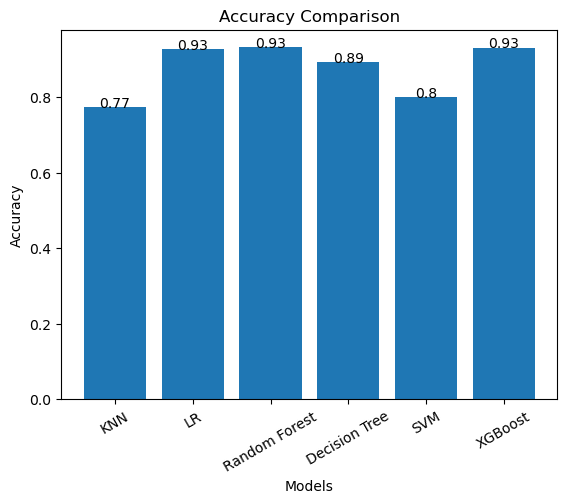

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = {
    "KNN": KNeighborsClassifier(),
    "LR": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


names = []
scores = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_valid)
    acc = accuracy_score(y_valid, y_pred)
    
    names.append(name)
    scores.append(acc)


# Plot graph
plt.figure()
plt.bar(names, scores)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
for i, v in enumerate(scores):
    plt.text(i, v, str(round(v,2)), ha='center') 
plt.xticks(rotation=30)
plt.show()

In [51]:
##  RandomizedSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2', None],
    
}
random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_dist,
    n_iter=10,  
    cv=5,
    random_state=42
)
random_search.fit(x_train, y_train)

print("RandomizedSearchCV Best Parameters:", random_search.best_params_)
print("RandomizedSearchCV Best CV Accuracy:", random_search.best_score_)

RandomizedSearchCV Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 104}
RandomizedSearchCV Best CV Accuracy: 0.9258042734207261


In [52]:
# Classification Report (Current RF Model)
from sklearn.metrics import classification_report, confusion_matrix
ypred_rf = rf.predict(x_valid)
print("=== Classification Report (RF Base Model) ===")
print(classification_report(y_valid, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_pred))


=== Classification Report (RF Base Model) ===
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       424
           1       0.94      0.97      0.96      1699

    accuracy                           0.93      2123
   macro avg       0.91      0.87      0.89      2123
weighted avg       0.93      0.93      0.93      2123


Confusion Matrix:
[[ 328   96]
 [  50 1649]]


Top 10 Features:
                feature  importance
9        Credit_History    0.475630
15     Total_Income_log    0.058228
11  ApplicantIncome_log    0.056307
13          TotalIncome    0.054893
5       ApplicantIncome    0.053644
14      LoanIncomeRatio    0.047478
12       LoanAmount_log    0.042742
7            LoanAmount    0.041708
2            Dependents    0.037425
6     CoapplicantIncome    0.035064


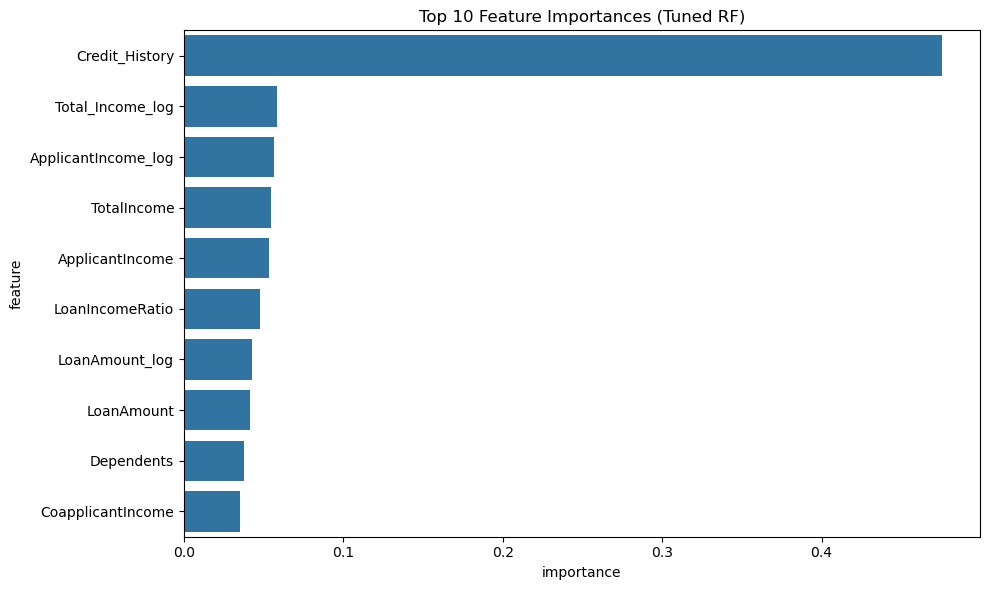

In [53]:
# 8.4 Feature Importance & Visualization

importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'feature': x_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

print("Top 10 Features:")
print(feat_imp)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Top 10 Feature Importances (Tuned RF)')
plt.tight_layout()
plt.show()


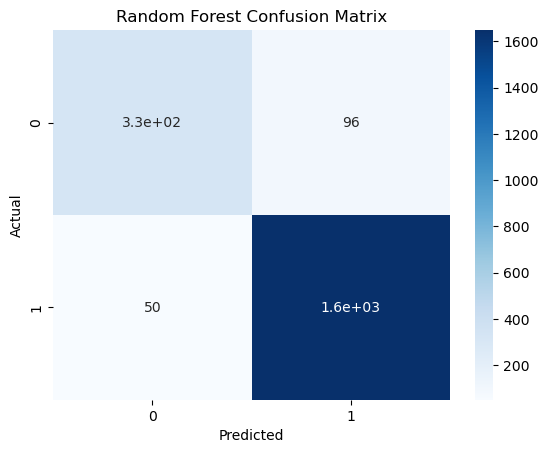

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

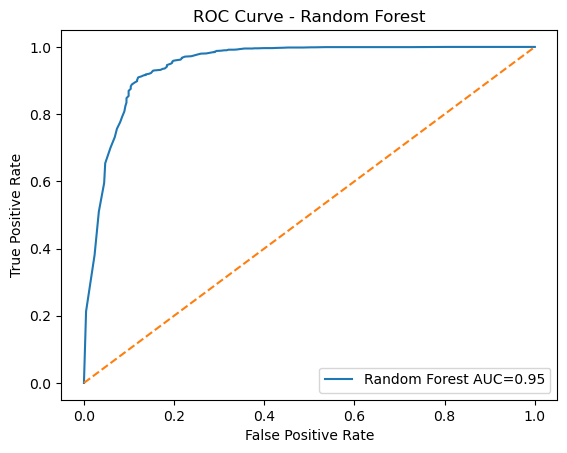

In [55]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf.predict_proba(x_valid)[:,1]

fpr, tpr, _ = roc_curve(y_valid, rf_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Random Forest AUC="+str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [56]:
import joblib 
model_bundle = {
    "model":           rf,
    "scaler":          scaler,
    "label_encoders":  le,
    "feature_columns": x.columns.tolist(),
}
joblib.dump(model_bundle, "loan_project_final.pkl")
print("\n✅ Model saved to loan_project_final.pkl")


✅ Model saved to loan_project_final.pkl


In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 1. LOAD TRAINED RANDOM FOREST MODEL
# ==============================
model = joblib.load("loan_model.pkl")   # your trained RF model

# ==============================
# 2. LOAD TEST DATA
# ==============================
df = pd.read_csv("Test_new.csv")

print("Test Data:")
print(df.head())

# ==============================
# 3. BASIC PREPROCESSING
# (must match training)
# ==============================

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Convert categorical → numeric
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

# ==============================
# 4. SPLIT INPUT & OUTPUT
# ==============================
if 'Loan_Status' in df.columns:
    X_test = df.drop('Loan_Status', axis=1)
    y_test = df['Loan_Status']
else:
    X_test = df
    y_test = None

# ==============================
# 5. PREDICT
# ==============================
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)

# ==============================
# 6. EVALUATION
# ==============================
if y_test is not None:
    accuracy = accuracy_score(y_test, y_pred)

    print("\nAccuracy:", accuracy)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Show correct/incorrect
    result = X_test.copy()
    result['Actual'] = y_test
    result['Predicted'] = y_pred
    result['Correct'] = result['Actual'] == result['Predicted']

    print("\nResult Sample:")
    print(result.head())

    # Save output
    result.to_csv("rf_test_results.csv", index=False)
    print("\nSaved file → rf_test_results.csv")

else:
    print("\nNo actual values found → only predictions shown")

    result = X_test.copy()
    result['Predicted'] = y_pred
    result.to_csv("rf_predictions.csv", index=False)

In [79]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
 # predict accuracy
y_pred = rf.predict(x_valid)
print("Accuracy",accuracy_score(y_valid,y_pred))
y_pred_test = rf.predict(x_valid)
pred = ['Y' if p == 1 else 'N' for p in y_pred_test]
# print(pred)

Accuracy 0.9349976448422044
